# Global Earthquake 2020-2026

##### https://www.kaggle.com/datasets/zaneneave/global-earthquakes-2020-2026

### This jupyter notebook file contains data cleaning of the dataset - Global Earthquakes-2020-2026 - where the following steps have been followed
#### 1. Understanding the data
#### 2. Imputing the data (Handling Null Values)
#### 3. Standardisation and normalisation - 
#### 4. Removing skewness from the data using PowerTransformer

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
data = pd.read_csv("global_earthquakes_2020_2026.csv")

data.head()

,id,time,year,decade,latitude,longitude,depth,mag,magType,place,...,mag_category,nst,gap,dmin,rms,horizontalError,depthError,magError,status,net
0,us70006t13,2020-01-01 00:28:20.289000+00:00,2020,2020,-5.3245,152.5514,40.24,5.1,mb,"112 km SSE of Kokopo, Papua New Guinea",...,5.0-5.5,NaN,74.0,1.190,0.79,9.4,6.3,0.044,reviewed,us
1,us70006t2a,2020-01-01 03:53:29.023000+00:00,2020,2020,52.6367,159.1614,58.46,5.0,mb,"56 km SE of Petropavlovsk-Kamchatsky, Russia",...,NaN,NaN,94.0,0.496,0.66,7.7,4.6,0.026,reviewed,us
2,us70006t3c,2020-01-01 08:31:24.136000+00:00,2020,2020,-17.4280,-172.5044,10.00,5.4,mww,"207 km NE of Neiafu, Tonga",...,5.0-5.5,NaN,40.0,2.947,1.44,8.8,1.8,0.086,reviewed,us
3,us70006t6a,2020-01-01 16:34:59.178000+00:00,2020,2020,-53.0907,9.5001,10.00,5.0,mb,southwest of Africa,...,NaN,NaN,105.0,19.424,0.83,14.0,1.9,0.082,reviewed,us
4,us70006t6h,2020-01-01 16:51:32.285000+00:00,2020,2020,-30.2857,-71.5582,40.88,5.0,mwr,"42 km SSW of Coquimbo, Chile",...,NaN,NaN,117.0,0.392,0.72,5.0,2.5,0.038,reviewed,us


In [40]:
data.columns

Index(['id', 'time', 'year', 'decade', 'latitude', 'longitude', 'depth', 'mag',
       'magType', 'place', 'region', 'mag_category', 'nst', 'gap', 'dmin',
       'rms', 'horizontalError', 'depthError', 'magError', 'status', 'net'],
      dtype='str')

In [ ]:
data.tail(4)

In [22]:
data.shape

(11808, 21)

In [ ]:
data.info()

In [ ]:
data.duplicated().sum()

In [ ]:
data.isnull().sum()

In [24]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
year,11808.0,2022.848577,1.894017,2020.0000,2021.000000,2023.0000,2025.00000,2026.0000
decade,11808.0,2020.000000,0.000000,2020.0000,2020.000000,2020.0000,2020.00000,2020.0000
latitude,11808.0,-1.107176,33.074095,-69.7739,-23.257025,-4.3305,25.14815,87.3860
longitude,11808.0,35.680500,123.549638,-179.9896,-71.966100,95.0412,143.24010,179.9981
depth,11808.0,50.811189,97.330476,0.8000,10.000000,10.4425,45.55900,676.4690
mag,11808.0,5.324002,0.395378,5.0000,5.000000,5.2000,5.50000,8.8000
nst,7536.0,112.138402,61.418156,0.0000,70.000000,101.0000,136.00000,619.0000
gap,11722.0,64.091780,35.171445,8.0000,38.000000,57.0000,82.00000,278.0000
dmin,11718.0,4.376859,5.188099,0.0000,1.352000,2.5970,5.41150,41.0460
rms,11777.0,0.761374,0.212748,0.0600,0.610000,0.7400,0.89000,2.0000


In [43]:
data.describe(include="str").T

,count,unique,top,freq
id,11808,11808,us70006t13,1
time,11808,11808,2020-01-01 00:28:20.289000+00:00,1
magType,11808,9,mww,7124
place,11808,7322,South Sandwich Islands region,706
region,11808,296,Indonesia,1025
mag_category,8827,5,5.0-5.5,6445
status,11808,1,reviewed,11808
net,11808,12,us,11642


In [ ]:
data['mag_category'].unique()

In [ ]:
data['net'].unique()

In [44]:
data['magType'].unique()

<StringArray>
['mb', 'mww', 'mwr', 'mwp', 'mw', 'ml', 'mwb', 'mwc', 'ml(texnet)']
Length: 9, dtype: str

# Null values

In [21]:
null_counts = data.isnull().sum()
null_counts[null_counts > 0]

mag_category       2981
nst                4272
gap                  86
dmin                 90
rms                  31
horizontalError      95
magError             93
dtype: int64

In [23]:
data.isnull().sum()/len(data)
#determines whether we should drop the coulmn or not -> we don't drop as no colum has >0.5 null value

id                 0.000000
time               0.000000
year               0.000000
decade             0.000000
latitude           0.000000
longitude          0.000000
depth              0.000000
mag                0.000000
magType            0.000000
place              0.000000
region             0.000000
mag_category       0.252456
nst                0.361789
gap                0.007283
dmin               0.007622
rms                0.002625
horizontalError    0.008045
depthError         0.000000
magError           0.007876
status             0.000000
net                0.000000
dtype: float64

In [ ]:
df1['nstMean'].isnull().sum()

In [ ]:
df1['mag_category_new'].isnull().sum()

### NULL values handling

mag_category       2981 DONE bining
nst                4272 DONE mean
gap                  86 DONE median
dmin                 90 DONE median
rms                  31 DONE median -> median wiuld be best measure as the data is skewed
horizontalError      95 DONE mean -> not much skew 
magError             93 DONE median

In [3]:
df1 = data.copy()

In [4]:
df1 = df1.drop(columns=['status'])

In [32]:
df1 = df1.drop(columns=['nst_yeojohnson'])

### nst values handling

In [ ]:
df1['nst'].skew()

In [30]:
(df1['nst']<0).any()

np.False_

In [29]:
#since there is a large +ve skew, will be handling the skew first and then the null values
# i could go with log or yeo-johnson as im NOT dealing with -ve values, and  the values aren't too big 
pt_boxcox= PowerTransformer(method="boxcox")
df1["nst_boxcox"] = pt_yeojohnson.fit_transform(df1[["nstMedian"]])
print("After boxcox Transformer, the skewness is ", df1["nst_boxcox"].skew())

#### Turns out you need to handle null values first before transformatiom

After boxcox Transformer, the skewness is  0.06881997254674556


In [5]:
col = 'nst'
df1['nstMedian'] =df1[col].fillna(df1[col].median()) 

##### Binning for mag_error

In [ ]:
data['mag'].max()

In [6]:
#['5.0-5.5', nan, '5.5-6.0', '6.0-6.5', '6.5-7.0', '7.0+']
df1['mag_category_new'] = pd.cut(df1['mag'],
                        bins=[4.9, 5.5, 6.0, 6.5, 7.0, 8.9],
                        labels=['5.0-5.5', '5.5-6.0', '6.0-6.5', '6.5-7.0', '7.0+'])
df1[['mag','mag_category', 'mag_category_new']]

,mag,mag_category,mag_category_new
0,5.1,5.0-5.5,5.0-5.5
1,5.0,NaN,5.0-5.5
2,5.4,5.0-5.5,5.0-5.5
3,5.0,NaN,5.0-5.5
4,5.0,NaN,5.0-5.5
...,...,...,...
11803,5.3,5.0-5.5,5.0-5.5
11804,5.1,5.0-5.5,5.0-5.5
11805,6.2,6.0-6.5,6.0-6.5
11806,5.4,5.0-5.5,5.0-5.5


##### Median for rms

In [ ]:
data['rms'].skew()

In [ ]:
sns.set_theme()
plt.figure(figsize= (10,4)) #SETS THE CANVAS SIZE
sns.histplot(data = data, x="rms", bins = 50) # Histogram plotting, bins means the bars, here we want the data in 25 parts
plt.xlabel("rms")
plt.title("RMS")
plt.show()

In [7]:
df1['rms-median'] = df1['rms'].fillna(df1['rms'].median())
df1['rms-median']

0        0.79
1        0.66
2        1.44
3        0.83
4        0.72
         ... 
11803    1.02
11804    0.95
11805    0.74
11806    0.77
11807    0.95
Name: rms-median, Length: 11808, dtype: float64

##### gap - median

In [ ]:
df1['gap'].skew()

In [8]:
df1['gap-median'] = df1['gap'].fillna(df1['gap'].median())
df1['gap-median']

0         74.0
1         94.0
2         40.0
3        105.0
4        117.0
         ...  
11803     84.0
11804    105.0
11805     24.0
11806    131.0
11807     88.0
Name: gap-median, Length: 11808, dtype: float64

##### dmin -median

In [ ]:
df1['dmin-median'] = df1['dmin'].fillna(data['dmin'].median())
df1['dmin-median']

##### horizontalError Handling

In [ ]:
df1['horizontalError'].skew()

In [9]:
df1['horizontalError-mean'] = data['horizontalError'].fillna(data['horizontalError'].mean())
df1['horizontalError-mean']

0         9.40
1         7.70
2         8.80
3        14.00
4         5.00
         ...  
11803     4.68
11804     4.27
11805     8.29
11806     4.67
11807    11.75
Name: horizontalError-mean, Length: 11808, dtype: float64

##### MagError Median

In [10]:
df1['magError-median'] = data['magError'].fillna(data['magError'].median())
df1['magError-median']

0        0.044
1        0.026
2        0.086
3        0.082
4        0.038
         ...  
11803    0.080
11804    0.061
11805    0.044
11806    0.065
11807    0.089
Name: magError-median, Length: 11808, dtype: float64

### Standardisation/Normalisation

Not possible with exclude = obj as mag category is considered a string but since it has numeric values python is 
trying to convert it to a float, which is not possible

In [33]:
sc = StandardScaler()
cols = df1.select_dtypes(include='number').columns.tolist()
df_std = pd.DataFrame(sc.fit_transform(df1[cols]), columns = cols)
df_std

,year,decade,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,nstMedian,rms-median,gap-median,horizontalError-mean,magError-median,rms-boxcox,nst_boxcox
0,-1.504051,0.0,-0.127517,0.945983,-0.108616,-0.566575,NaN,0.281724,-0.614290,0.134558,0.615178,1.558280,-0.909599,-0.144035,0.134998,0.284188,0.617668,-0.912535,0.195657,0.009255
1,-1.504051,0.0,1.625023,0.999486,0.078589,-0.819508,NaN,0.850391,-0.748063,-0.476518,-0.087477,0.766712,-1.619419,-0.144035,-0.476874,0.854853,-0.087831,-1.625148,-0.427342,0.009255
2,-1.504051,0.0,-0.493483,-1.685102,-0.419323,0.192224,NaN,-0.685010,-0.275615,3.189940,0.367182,-0.537046,0.746647,-0.144035,3.194358,-0.685943,0.368668,0.750230,2.791216,0.009255
3,-1.504051,0.0,-1.571796,-0.211911,-0.419323,-0.819508,NaN,1.163158,2.900443,0.322582,2.516478,-0.490483,0.588909,-0.144035,0.323266,1.168718,2.526663,0.591871,0.378005,0.009255
4,-1.504051,0.0,-0.882254,-0.868017,-0.102040,-0.819508,NaN,1.504359,-0.768110,-0.194483,-1.203458,-0.211107,-1.146206,-0.144035,-0.194472,1.511118,-1.208328,-1.150072,-0.133617,0.009255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11803,1.663953,0.0,1.670646,-1.604472,-0.103139,-0.060709,0.258273,0.566058,-0.682333,1.215693,-1.335722,1.783644,0.510040,0.403037,1.217540,0.569520,-1.341128,0.512692,1.195497,0.577937
11804,1.663953,0.0,0.205522,0.726563,-0.273936,-0.566575,-0.865248,1.163158,-0.578244,0.886652,-1.505186,0.929217,-0.239214,-0.995036,0.888071,1.168718,-1.511277,-0.239511,0.902888,-1.183941
11805,1.663953,0.0,0.194543,0.724314,0.175110,2.215687,0.746760,-1.139944,-0.500756,-0.100471,0.156386,1.536861,-0.909599,1.010895,-0.100338,-1.142475,0.157019,-0.912535,-0.038143,1.106598
11806,1.663953,0.0,1.671563,-1.605241,-0.038707,0.192224,0.128010,1.902426,-0.689658,0.040546,-1.339855,1.083805,-0.081476,0.240942,0.040863,1.910583,-1.345278,-0.081153,0.102948,0.420319


In [12]:
mnmx = MinMaxScaler()
df_mnmx = pd.DataFrame(mnmx.fit_transform(df1[cols]), columns = cols)
df_mnmx

,year,decade,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError
0,0.0,0.0,0.410088,0.923757,0.058372,0.026316,NaN,0.244444,0.028992,0.376289,0.541475,0.121622,0.100000
1,0.0,0.0,0.778892,0.942118,0.085338,0.000000,NaN,0.318519,0.012084,0.309278,0.443548,0.088803,0.059091
2,0.0,0.0,0.333074,0.020793,0.013616,0.105263,NaN,0.118519,0.071797,0.711340,0.506912,0.034749,0.195455
3,0.0,0.0,0.106154,0.526378,0.013616,0.000000,NaN,0.359259,0.473225,0.396907,0.806452,0.036680,0.186364
4,0.0,0.0,0.251261,0.301209,0.059319,0.000000,NaN,0.403704,0.009550,0.340206,0.288018,0.048263,0.086364
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11803,1.0,0.0,0.788493,0.048464,0.059161,0.078947,0.206785,0.281481,0.020392,0.494845,0.269585,0.130965,0.181818
11804,1.0,0.0,0.480173,0.848454,0.034558,0.026316,0.095315,0.359259,0.033548,0.458763,0.245968,0.095541,0.138636
11805,1.0,0.0,0.477862,0.847682,0.099241,0.315789,0.255250,0.059259,0.043342,0.350515,0.477535,0.120734,0.100000
11806,1.0,0.0,0.788686,0.048200,0.068442,0.105263,0.193861,0.455556,0.019466,0.365979,0.269009,0.101950,0.147727


### PowerTransformer

In [31]:
(df1['rms']<0).any()

np.False_

In [18]:
pt_boxcox = PowerTransformer(method="box-cox")
df1["rms-boxcox"] = pt_boxcox.fit_transform(data[["rms"]])
print("After boxcox Transformer, the skewness is ", df1["rms-boxcox"].skew())

After boxcox Transformer, the skewness is  0.03415946903578333


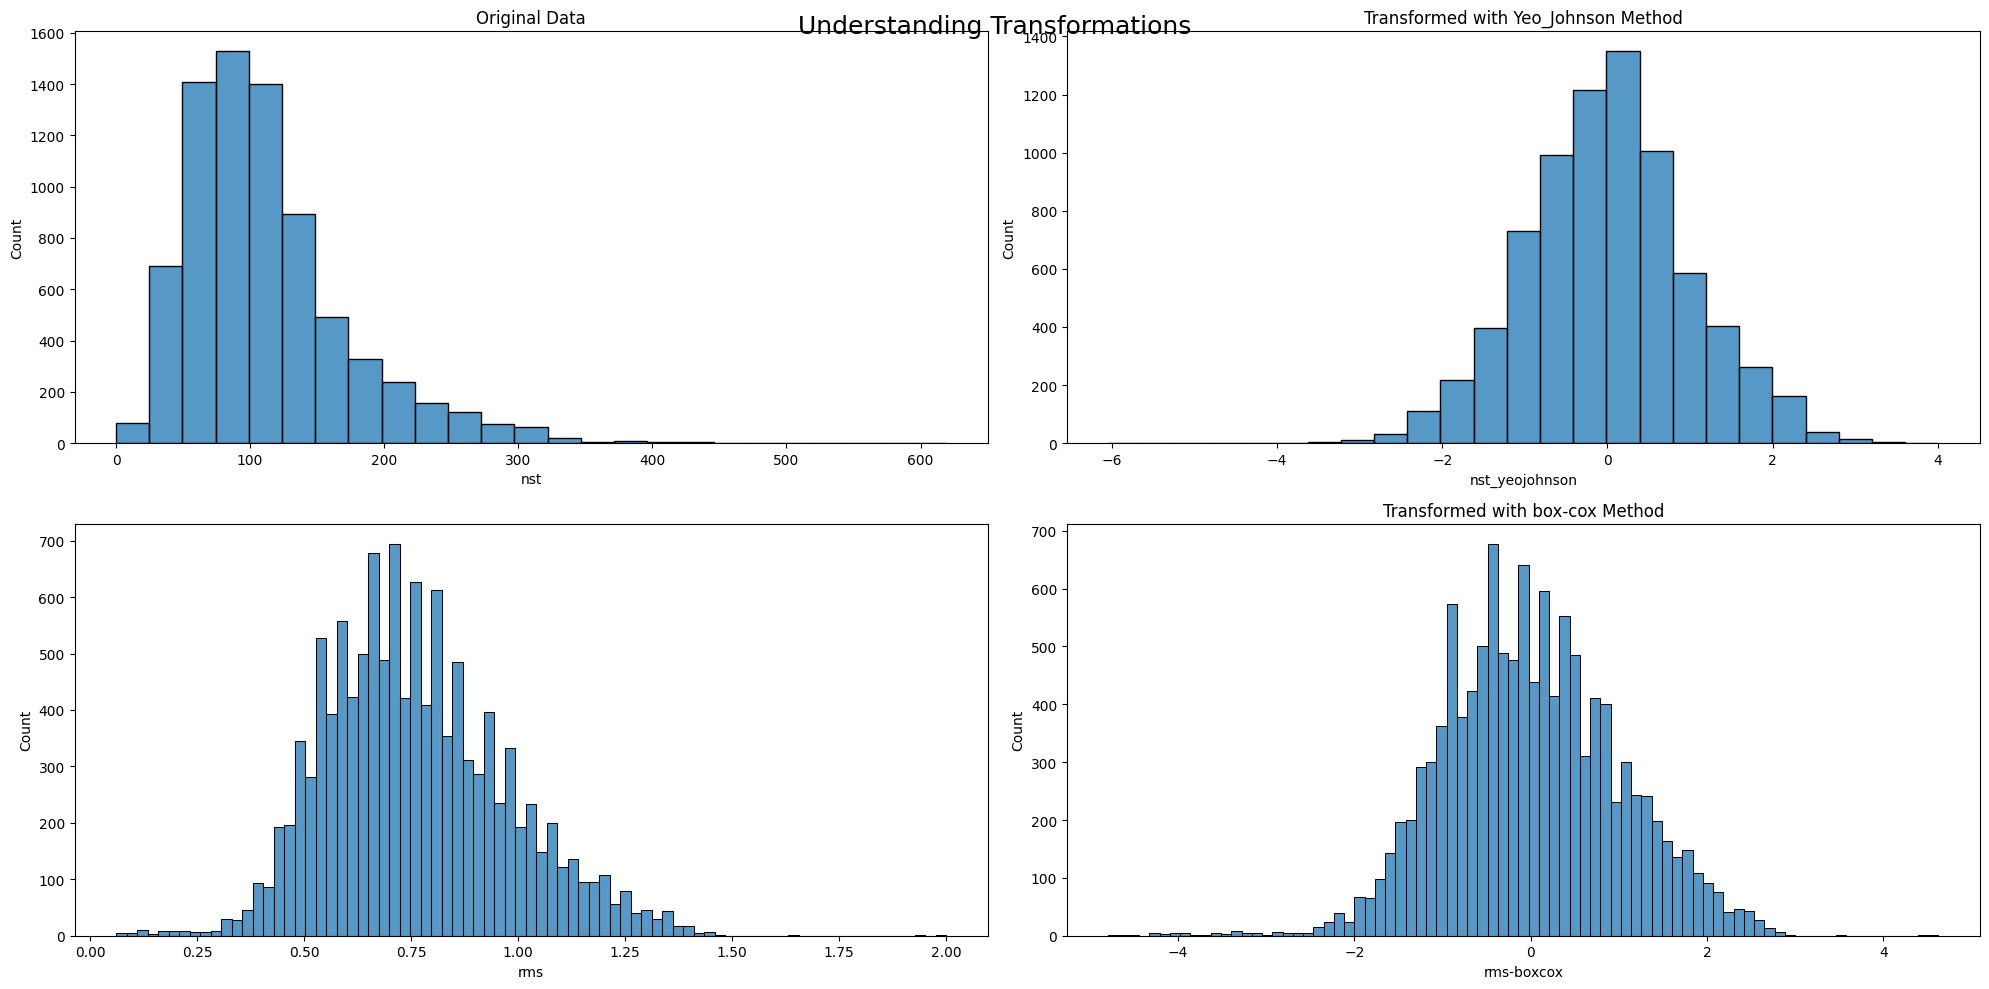

In [20]:
plt.figure(figsize= (20, 10)) #SETS THE CANVAS SIZE
plt.subplot(2,2,1)
sns.histplot(data = df1, x="nst", bins = 25) 
plt.title("Original Data")

plt.subplot(2,2,2)
sns.histplot(data = df1, x ="nst_yeojohnson", bins = 25)
plt.title("Transformed with Yeo_Johnson Method")
plt.tight_layout()

plt.subplot(2,2,3)
sns.histplot(data = df1, x="rms") 

plt.subplot(2,2,4)
sns.histplot(data = df1, x ="rms-boxcox")
plt.title("Transformed with box-cox Method")

plt.tight_layout()
plt.suptitle("Understanding Transformations", fontsize = 18)
plt.show()

In [38]:
df1.head()

,id,time,year,decade,latitude,longitude,depth,mag,magType,place,...,magError,net,nstMedian,mag_category_new,rms-median,gap-median,horizontalError-mean,magError-median,rms-boxcox,nst_boxcox
0,us70006t13,2020-01-01 00:28:20.289000+00:00,2020,2020,-5.3245,152.5514,40.24,5.1,mb,"112 km SSE of Kokopo, Papua New Guinea",...,0.044,us,101.0,5.0-5.5,0.79,74.0,9.4,0.044,0.195657,0.009255
1,us70006t2a,2020-01-01 03:53:29.023000+00:00,2020,2020,52.6367,159.1614,58.46,5.0,mb,"56 km SE of Petropavlovsk-Kamchatsky, Russia",...,0.026,us,101.0,5.0-5.5,0.66,94.0,7.7,0.026,-0.427342,0.009255
2,us70006t3c,2020-01-01 08:31:24.136000+00:00,2020,2020,-17.4280,-172.5044,10.00,5.4,mww,"207 km NE of Neiafu, Tonga",...,0.086,us,101.0,5.0-5.5,1.44,40.0,8.8,0.086,2.791216,0.009255
3,us70006t6a,2020-01-01 16:34:59.178000+00:00,2020,2020,-53.0907,9.5001,10.00,5.0,mb,southwest of Africa,...,0.082,us,101.0,5.0-5.5,0.83,105.0,14.0,0.082,0.378005,0.009255
4,us70006t6h,2020-01-01 16:51:32.285000+00:00,2020,2020,-30.2857,-71.5582,40.88,5.0,mwr,"42 km SSW of Coquimbo, Chile",...,0.038,us,101.0,5.0-5.5,0.72,117.0,5.0,0.038,-0.133617,0.009255


In [39]:
df1.to_csv('final-Global-Earthquake-2020-2026.csv', index=False)

## Understanding My data

In [34]:
df1['depth'].corr(df1['mag'])

np.float64(0.09498940415588655)

Depth of an erthquake has low +ve correlation to the magnitude of an earthquake

In [42]:
df1.loc[df1['mag'] > 6, 'magType']

27       mww
28        mw
38       mww
84       mww
86       mww
        ... 
11742    mww
11784    mww
11794    mww
11795    mww
11805    mww
Name: magType, Length: 682, dtype: str

While mL is the standard type of measurement of magnitude, mWW is used most as the data is primarily US affiliated data

In [46]:
df1['dmin'].corr(df1['depthError'])

np.float64(-0.15957266100793596)

## Things I learnt
#### Null values hae to be handled before transformation for reducing skewness through transformation methods
#### Median is more commonly used and a much better option than mean with imputing data when the data is skewed
#### Earthquakes are a very common occurence around the world and a lot of data, calculations and sciences go into each and every aspect of understanding it
#### There are different scales of measurement of magnitudes mL is for regional and small scale earthquakes while mW is much large scale and modern, and mWW is used by the U.S. Geological Survey (USGS), indicating that the data is primarily from the US
#### Depth of an erthquake has low +ve correlation to the magnitude of an earthquake - the depth of the earthquake doesn't really determine the magnitude of it